In [22]:
import numpy as np 
import pandas as pd
import json
import os 

pd.set_option('display.max_columns', None)

## Combining Json Data

In [23]:
def json_loader(json_path):
    """
    Loads a JSON dump created by ticker_to_json.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def generate_return_with_dividends(
        df: pd.DataFrame, 
        window: int, 
        buy_price: str = 'close', 
        sell_price: str = 'open'
    ):
    '''
    Computes the return over a given horizon including dividends.
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing price and dividend information.
    window : int
        The number of periods over which to compute the return.
        Negative window means looking forward from current date.
        Positive window means looking backward to current date.
    buy_price : str
        The column name for the starting price.
    sell_price : str
        The column name for the ending price.
    '''
    grp = df.groupby("ticker")
    
    # Calculate outcome return including dividends
    # Assumption: we'll buy stock each day at closing price and sell at next day's open price.
    # Return takes into account dividends received during holding period.
    div = grp['dividends'].rolling(window=np.abs(window), min_periods=1).sum().shift(window)
    end_price = grp[sell_price].shift(window)
    new_price = end_price + div
    out = (new_price - df[buy_price]) / df[buy_price]
    return out.reset_index(level=0, drop=True)


def preprocess_feature(
    df,
    buy_price="close",
    sell_price = "open",
    outcome_window_stock = (7, 30),
    feature_window_stock = (7, 30),
    feature_window_market = (7, 30)
):
    """
    df: DataFrame with at least columns ['ticker', 'date', buy_price, 'volume'].
        Index can be anything (e.g. row_id); we reset it.
    buy_price: which price to use for buying the stock.
    sell_price: which price to use for selling the stock after holding period.
    outcome_window_stock: rolling windows (in days) for stock-level outcome returns.
    feature_window_stock: rolling windows (in days) for stock-level features.
    feature_window_market: windows for market-level momentum features.

    Returns: DataFrame with added feature columns.
    """
    # --- Ensure proper types and sort ---
    #df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])

    # Make a MultiIndex: (ticker, date)
    #df = df.set_index(["ticker", "date"])

    # --- 1) Per-stock daily returns ---
    for w in outcome_window_stock:
        df[f"out_ret_{w}d"] = generate_return_with_dividends(
            df,
            window = -w,
            buy_price=buy_price,
            sell_price=sell_price
        )

    # --- 2) Stock-level historical features (X days return, momentum, volatility, volume avg) ---

    #If there is not one day momentum column, create it
    df['mom_1d'] = generate_return_with_dividends(
            df,
            window = 1,
            buy_price=buy_price,
            sell_price=sell_price
        )

    for w in feature_window_stock:
        grp = df.groupby("ticker")
        
        df[f"mom_{w}d"] = generate_return_with_dividends(
            df,
            window = w,
            buy_price=buy_price,
            sell_price=sell_price
        )

        # rolling volatility of daily returns
        vol = grp[f"mom_1d"].rolling(window=w, min_periods=w).std()
        #df[f"vol_{w}d"] = vol.reset_index(level=0, drop=True)
        df[f"std_{w}d"] = vol.reset_index(level=0, drop=True)

        # rolling average volume
        avg_vol = grp["volume"].rolling(window=w, min_periods=w).mean()
        df[f"avg_vol_{w}d"] = avg_vol.reset_index(level=0, drop=True)

        # rolling mean price (historical average price level)
        ma_price = grp[buy_price].rolling(window=w, min_periods=w).mean()
        df[f"ma_price_{w}d"] = ma_price.reset_index(level=0, drop=True)


    # --- 3) Market-level daily return (equal-weight across all stocks) ---
    # equal-weighted "market" daily return
    mkt_df_list = list()

    mkt_df = df.groupby("date")['mom_1d'].mean().reset_index().rename(columns={'mom_1d': 'mkt_mom_1d'})
    # --- 4) Market-level momentum over windows ---
    for w in feature_window_market:
        # compound (1 + mkt_ret) over window, minus 1
        mkt_df[f"mkt_mom_{w}d"] = (
            (1 + mkt_df["mkt_mom_1d"])
            .rolling(window=w, min_periods=w)
            .apply(lambda x: np.prod(x) - 1, raw=False)
        )

    df = df.merge(
        mkt_df,
        on="date",
        how="left"
    )

    # Drop 1 day market momentum column necessary for calculation only unless 1D is in feature_window_market
    if 1 not in feature_window_market:
        df = df.drop(columns=['mkt_mom_1d', 'mom_1d'])
        
    return df


def filter_by_cycle(
    df: pd.DataFrame,
    cycle: int = 7
    ) -> pd.DataFrame:
    """
    Filters the DataFrame to include only rows where the index modulo cycle is zero.
    """ 
    return df.loc[(np.arange(len(df)) % cycle) == 0]


## Load Data for Model

In [24]:
price_df = pd.read_csv("data/price_history_5y_daily.csv", parse_dates=["date"])
price_df['row_id'] = price_df['ticker'] + price_df['date'].apply(lambda x: x.strftime("%Y%m%d"))
price_df = price_df.set_index('row_id')

price_df_sample = price_df.loc[price_df.ticker.isin(price_df.ticker.unique()[:5])].copy()

In [25]:
price_df_sample.groupby("ticker").shift(-7)[['open', 'high', 'low', 'close']].head(10)

,open,high,low,close
row_id,,,,
AAPL20201207,124.027556,124.962062,123.200116,124.416931
AAPL20201208,125.478013,126.139968,124.640843,125.283325
AAPL20201209,125.536429,125.672712,122.771820,123.297485
AAPL20201210,121.701002,124.903661,120.172682,124.825783
AAPL20201211,128.116070,130.841740,126.208097,128.378906
AAPL20201214,128.651454,128.914276,127.308085,127.483315
AAPL20201215,127.833754,129.916941,127.619593,128.466492
AAPL20201216,130.432885,133.693941,129.965617,133.061203
AAPL20201217,134.385060,135.105405,130.773546,131.289474


In [26]:
metadata = pd.read_csv("data/metadata.csv", encoding='cp1252')
metadata.columns = [cap.replace(' ', '_').replace('\xa0', '_').replace('-', '').lower() for cap in metadata.columns]
metadata['gics_sector'].value_counts()

gics_sector
Industrials               79
Financials                75
Information Technology    68
Health Care               60
Consumer Discretionary    50
Consumer Staples          37
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    24
Energy                    22
Name: count, dtype: int64

In [27]:
sector = pd.get_dummies(metadata.set_index('symbol')['gics_sector'], drop_first=True).astype(int)
sector.columns = [col.replace(' ', '_').lower() for col in sector.columns]

In [28]:
outdata = preprocess_feature(
    price_df,
    buy_price="close",
    sell_price="open",
    outcome_window_stock=[7, 30],
    feature_window_stock=[7, 21, 63],
    feature_window_market=[7, 21, 63],
)

outdata = outdata.merge(sector, right_index=True, left_on='ticker', how='left')
outdata = filter_by_cycle(outdata, cycle=7).reset_index(drop=True)
outdata = outdata.dropna().reset_index(drop=True)

outdata['date'] = pd.to_datetime(outdata['date'], utc=True)
outdata = outdata.sort_values(["ticker", "date"])

In [29]:
outdata.head()

,date,open,high,low,close,volume,dividends,stock_splits,ticker,out_ret_7d,out_ret_30d,mom_7d,std_7d,avg_vol_7d,ma_price_7d,mom_21d,std_21d,avg_vol_21d,ma_price_21d,mom_63d,std_63d,avg_vol_63d,ma_price_63d,mkt_mom_7d,mkt_mom_21d,mkt_mom_63d,consumer_discretionary,consumer_staples,energy,financials,health_care,industrials,information_technology,materials,real_estate,utilities
0,2021-03-10 05:00:00+00:00,116.752613,118.321064,115.881258,116.171707,1934600.0,0.0,0.0,A,0.024002,0.120380,0.025502,0.034900,2.148357e+06,114.795516,0.032753,0.025780,1.914333e+06,119.198887,-0.041492,0.020955,1.748452e+06,118.140252,0.004048,-0.001384,-0.043168,0,0,0,0,1,0,0,0,0,0
1,2021-03-19 04:00:00+00:00,118.960085,119.570035,117.643362,118.785812,2597000.0,0.0,0.0,A,0.015649,0.097846,-0.017117,0.015381,1.697200e+06,118.686220,0.051430,0.024946,1.823414e+06,117.774284,-0.043219,0.020964,1.760251e+06,118.714796,-0.019242,-0.013270,-0.066292,0,0,0,0,1,0,0,0,0,0
2,2021-03-30 04:00:00+00:00,120.644701,121.700012,120.451069,120.867378,1033700.0,0.0,0.0,A,0.056236,0.047250,-0.015780,0.018721,1.367329e+06,119.532687,-0.014338,0.024670,1.737629e+06,117.671474,-0.052259,0.021698,1.709483e+06,119.325244,-0.020229,-0.035192,-0.082620,0,0,0,0,1,0,0,0,0,0
3,2021-04-09 04:00:00+00:00,127.470421,127.916452,126.762564,127.906761,1552200.0,0.0,0.0,A,0.008263,0.005761,-0.056776,0.010047,1.299043e+06,125.697704,-0.087205,0.014564,1.454524e+06,121.305537,-0.057379,0.020204,1.663016e+06,120.385194,-0.032143,-0.069969,-0.082640,0,0,0,0,1,0,0,0,0,0
4,2021-04-20 04:00:00+00:00,128.963654,129.496965,127.819472,128.440048,1261200.0,0.0,0.0,A,0.022271,0.035180,-0.006039,0.010860,1.886971e+06,128.829290,-0.073808,0.013492,1.517781e+06,124.686560,-0.038302,0.020063,1.691754e+06,121.041329,-0.007581,-0.058911,-0.077572,0,0,0,0,1,0,0,0,0,0


##### Financials Data

In [30]:
financials_df = pd.read_csv("data/company_financials.csv")

In [31]:
financials_df['date'] = pd.to_datetime(financials_df['date'], utc=True)

#Assume 45D lags in financial reporting
financials_df['report_date'] = financials_df['date'] + pd.Timedelta('45d')

financials_df = financials_df.sort_values(["ticker", "report_date"])

In [32]:
financials_df[['report_date', 'ticker']].value_counts()

report_date                ticker
2024-07-15 00:00:00+00:00  DRI       2
2024-08-14 00:00:00+00:00  LRCX      2
2024-07-15 00:00:00+00:00  FDX       2
                           GIS       2
2024-08-14 00:00:00+00:00  MSFT      2
                                    ..
2025-12-15 00:00:00+00:00  TGT       1
                           TJX       1
                           WDAY      1
                           WMT       1
2021-02-14 00:00:00+00:00  AES       1
Name: count, Length: 5338, dtype: int64

In [33]:
financials_df = financials_df.groupby(['ticker', 'date']).mean().reset_index()

In [34]:
merged = pd.merge_asof(
    outdata.sort_values(["date", "ticker"]),
    financials_df.sort_values(["report_date", "ticker"]),
    left_on="date",
    right_on="report_date",
    by="ticker",
    direction="backward",
    tolerance=pd.Timedelta("180D")  # optional but recommended
)


In [14]:
signal_corr = merged[list(financials_df.drop(columns=['date', 'ticker']).columns) + [col for col in merged if 'out_ret_' in col]].corr(method='spearman')

In [15]:
strong_signal7d = signal_corr['out_ret_7d'].apply(np.abs).sort_values(ascending=False).head(20).index.tolist()
strong_signal30d = signal_corr['out_ret_30d'].apply(np.abs).sort_values(ascending=False).head(20).index.tolist()
strong_financial_signals = list(set(strong_signal7d + strong_signal30d))

In [16]:
merged = merged[[col for col in merged if (col not in financials_df.columns.difference(['date', 'ticker'])) or (col in strong_financial_signals)]]

In [17]:
missing_threshold = 0.6
high_missing_cols = merged.isna().mean()[merged.isna().mean()>missing_threshold].index.tolist()
merged = merged.drop(columns=high_missing_cols)
merged = merged.dropna().reset_index(drop=True)

In [ ]:
def top_bottom_spread_by_date(df_pred: pd.DataFrame, pred_col="pred", y_col="target", date_col="date",
                              n_buckets=10):
    """
    Computes equal-weight top-decile minus bottom-decile spread per day, then averages.
    Returns:
      daily_spread: Series indexed by date
      avg_spread: float
    """
    dfp = df_pred.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col], utc=True)

    def _spread(g):
        g = g.dropna(subset=[pred_col, y_col])
        if len(g) < n_buckets * 5:  # skip very small cross-sections
            return np.nan
        g = g.sort_values(pred_col)
        # split into quantile buckets by rank (stable even if many ties)
        g["bucket"] = pd.qcut(np.arange(len(g)), q=n_buckets, labels=False)
        bot = g[g["bucket"] == 0][y_col].mean()
        top = g[g["bucket"] == n_buckets - 1][y_col].mean()
        return top - bot

    daily = dfp.groupby(date_col, sort=True).apply(_spread)
    avg = float(np.nanmean(daily.values))
    return daily, avg


In [ ]:
df_pred = merged
pred_col="outret_7d"
y_col="outret_7d"
date_col="date"
n_buckets=10

In [ ]:
dfp = df_pred.copy()
dfp[date_col] = pd.to_datetime(dfp[date_col], utc=True)

def _spread(g):
    g = g.dropna(subset=[pred_col, y_col])
    if len(g) < n_buckets * 5:  # skip very small cross-sections
        return np.nan
    g = g.sort_values(pred_col)
    # split into quantile buckets by rank (stable even if many ties)
    g["bucket"] = pd.qcut(np.arange(len(g)), q=n_buckets, labels=False)
    bot = g[g["bucket"] == 0][y_col].mean()
    top = g[g["bucket"] == n_buckets - 1][y_col].mean()
    return top - bot

daily = dfp.groupby(date_col, sort=True).apply(_spread)
avg = float(np.nanmean(daily.values))

In [35]:
merged.head()

,date_x,open,high,low,close,volume,dividends,stock_splits,ticker,out_ret_7d,out_ret_30d,mom_7d,std_7d,avg_vol_7d,ma_price_7d,mom_21d,std_21d,avg_vol_21d,ma_price_21d,mom_63d,std_63d,avg_vol_63d,ma_price_63d,mkt_mom_7d,mkt_mom_21d,mkt_mom_63d,consumer_discretionary,consumer_staples,energy,financials,health_care,industrials,information_technology,materials,real_estate,utilities,date_y,ordinary_shares_number,share_issued,net_debt,total_debt,tangible_book_value,invested_capital,working_capital,net_tangible_assets,common_stock_equity,total_capitalization,total_equity_gross_minority_interest,stockholders_equity,gains_losses_not_affecting_retained_earnings,other_equity_adjustments,retained_earnings,capital_stock,common_stock,total_liabilities_net_minority_interest,total_non_current_liabilities_net_minority_interest,other_non_current_liabilities,tradeand_other_payables_non_current,long_term_debt_and_capital_lease_obligation,long_term_debt,current_liabilities,other_current_liabilities,current_deferred_liabilities,current_deferred_revenue,current_debt_and_capital_lease_obligation,current_debt,other_current_borrowings,commercial_paper,payables_and_accrued_expenses,current_accrued_expenses,payables,total_tax_payable,income_tax_payable,accounts_payable,total_assets,total_non_current_assets,other_non_current_assets,non_current_deferred_assets,non_current_deferred_taxes_assets,investments_and_advances,investmentin_financial_assets,available_for_sale_securities,net_ppe,accumulated_depreciation,gross_ppe,leases,machinery_furniture_equipment,land_and_improvements,properties,current_assets,other_current_assets,inventory,finished_goods,raw_materials,receivables,other_receivables,accounts_receivable,cash_cash_equivalents_and_short_term_investments,other_short_term_investments,cash_and_cash_equivalents,cash_equivalents,cash_financial,treasury_shares_number,capital_lease_obligations,long_term_capital_lease_obligation,current_capital_lease_obligation,other_investments,other_properties,minority_interest,treasury_stock,additional_paid_in_capital,employee_benefits,non_current_pension_and_other_postretirement_benefit_plans,non_current_deferred_liabilities,non_current_deferred_taxes_liabilities,dividends_payable,goodwill_and_other_intangible_assets,other_intangible_assets,goodwill,construction_in_progress,buildings_and_improvements,work_in_process,prepaid_assets,pensionand_other_post_retirement_benefit_plans_current,other_payable,allowance_for_doubtful_accounts_receivable,gross_accounts_receivable,preferred_securities_outside_stock_equity,current_deferred_taxes_liabilities,current_provisions,restricted_cash,preferred_stock,preferred_shares_number,preferred_stock_equity,long_term_equity_investment,investments_in_other_ventures_under_equity_method,line_of_credit,non_current_deferred_revenue,interest_payable,current_notes_payable,hedging_assets_current,other_inventories,taxes_receivable,investmentsin_associatesat_cost,current_deferred_assets,non_current_accounts_receivable,held_to_maturity_securities,long_term_provisions,defined_pension_benefit,derivative_product_liabilities,financial_assets,assets_held_for_sale_current,receivables_adjustments_allowances,liabilities_heldfor_sale_non_current,non_current_note_receivables,foreign_currency_translation_adjustments,minimum_pension_liabilities,unrealized_gain_loss,loans_receivable,dueto_related_parties_current,investmentsin_joint_venturesat_cost,notes_receivable,inventories_adjustments_allowances,duefrom_related_parties_current,non_current_prepaid_assets,non_current_accrued_expenses,investment_properties,cash_cash_equivalents_and_federal_funds_sold,trading_securities,other_equity_interest,financial_assets_designatedas_fair_value_through_profitor_loss_total,investmentsin_subsidiariesat_cost,dueto_related_parties_non_current,current_deferred_taxes_assets,accrued_interest_receivable,duefrom_related_parties_non_current,restricted_common_stock,total_partnership_capital,limited_partnership_capital,free_cash_flow,repurcha

## Test Simple Modeling

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor
import shap


In [19]:
"""
End-to-end example: train XGBoost on a panel, benchmark performance, and make a SHAP summary plot.

Assumptions about your data:
- You already have a DataFrame `df` with columns:
    ['ticker', 'date', <feature columns...>, 'target_30d']
- (ticker, date) identify a row; date is daily; target_30d is your 30-trading-day ahead return (or log return).
- Features are already leak-safe (e.g., shifted if you predict at open).

Install:
    pip install xgboost shap scikit-learn pandas numpy matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor
import shap


# ----------------------------
# Utility: time split
# ----------------------------
def time_split(df: pd.DataFrame, date_col="date", train_end=None, valid_end=None):
    """
    Splits by date (no shuffling).
    - train: dates <= train_end
    - valid: train_end < dates <= valid_end
    - test : dates > valid_end
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True)

    if train_end is None:
        # default: 70% train, 15% valid, 15% test by unique dates
        dates = np.array(sorted(df[date_col].unique()))
        n = len(dates)
        train_end = dates[int(n * 0.70)]
        valid_end = dates[int(n * 0.85)]
    else:
        train_end = pd.to_datetime(train_end, utc=True)

        valid_end = pd.to_datetime(valid_end, utc=True) if valid_end is not None else train_end

    train = df[df[date_col] <= train_end]
    valid = df[(df[date_col] > train_end) & (df[date_col] <= valid_end)]
    test  = df[df[date_col] > valid_end]

    return train, valid, test, train_end, valid_end


# ----------------------------
# Utility: portfolio-style benchmark
# ----------------------------
def top_bottom_spread_by_date(df_pred: pd.DataFrame, pred_col="pred", y_col="target", date_col="date",
                              n_buckets=10):
    """
    Computes equal-weight top-decile minus bottom-decile spread per day, then averages.
    Returns:
      daily_spread: Series indexed by date
      avg_spread: float
    """
    dfp = df_pred.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col], utc=True)

    def _spread(g):
        g = g.dropna(subset=[pred_col, y_col])
        if len(g) < n_buckets * 5:  # skip very small cross-sections
            return np.nan
        g = g.sort_values(pred_col)
        # split into quantile buckets by rank (stable even if many ties)
        g["bucket"] = pd.qcut(np.arange(len(g)), q=n_buckets, labels=False)
        bot = g[g["bucket"] == 0][y_col].mean()
        top = g[g["bucket"] == n_buckets - 1][y_col].mean()
        return top - bot

    daily = dfp.groupby(date_col, sort=True).apply(_spread)
    avg = float(np.nanmean(daily.values))
    return daily, avg


def spearman_ic_by_date(df_pred: pd.DataFrame, pred_col="pred", y_col="target", date_col="date"):
    """
    Spearman information coefficient (rank correlation) computed cross-sectionally per date.
    Returns:
      daily_ic: Series
      mean_ic: float
    """
    dfp = df_pred.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col], utc=True)

    def _ic(g):
        g = g.dropna(subset=[pred_col, y_col])
        if len(g) < 20:
            return np.nan
        return g[pred_col].corr(g[y_col], method="spearman")

    daily = dfp.groupby(date_col, sort=True).apply(_ic)
    mean_ic = float(np.nanmean(daily.values))
    return daily, mean_ic


# ----------------------------
# Main: train + evaluate + SHAP
# ----------------------------
def train_xgb_and_benchmark(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "target_30d",
    ticker_col: str = "ticker",
    date_col: str = "date",
    train_end=None,
    valid_end=None,
    plot_shap: bool = True,
):
    # 0) Sort + split
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True)
    df = df.sort_values([date_col, ticker_col])

    train, valid, test, train_end, valid_end = time_split(df, date_col=date_col, train_end=train_end, valid_end=valid_end)

    X_train, y_train = train[feature_cols], train[target_col]
    X_valid, y_valid = valid[feature_cols], valid[target_col]
    X_test,  y_test  = test[feature_cols],  test[target_col]

    # 1) A reasonable starter config (strong regularization)
    model = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=20,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=5.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    # 2) Fit with early stopping on validation
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    # 3) Predictions
    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)
    pred_test  = model.predict(X_test)

    # 4) Standard regression metrics (useful sanity checks)
    def _reg_metrics(y_true, y_pred):
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae  = float(mean_absolute_error(y_true, y_pred))
        r2   = float(r2_score(y_true, y_pred))
        return {"rmse": rmse, "mae": mae, "r2": r2}

    metrics = {
        "train": _reg_metrics(y_train, pred_train),
        "valid": _reg_metrics(y_valid, pred_valid),
        "test":  _reg_metrics(y_test,  pred_test),
        "split": {"train_end": str(train_end), "valid_end": str(valid_end)},
    }

    # 5) Cross-sectional finance-style metrics (IC + top-bottom spread)
    test_eval = test[[ticker_col, date_col, target_col]].copy()
    test_eval["pred"] = pred_test
    test_eval = test_eval.rename(columns={target_col: "target"})

    daily_ic, mean_ic = spearman_ic_by_date(test_eval, pred_col="pred", y_col="target", date_col=date_col)
    daily_spread, avg_spread = top_bottom_spread_by_date(test_eval, pred_col="pred", y_col="target", date_col=date_col)

    metrics["test"]["mean_spearman_ic"] = mean_ic
    metrics["test"]["avg_top_minus_bottom_decile"] = avg_spread

    # 6) Optional plots: IC time series + spread time series
    fig1 = plt.figure()
    daily_ic.plot()
    plt.title("Daily Spearman IC (test)")
    plt.xlabel("Date")
    plt.ylabel("IC")
    plt.show()

    fig2 = plt.figure()
    daily_spread.plot()
    plt.title("Top-Decile minus Bottom-Decile Spread (test)")
    plt.xlabel("Date")
    plt.ylabel("Spread (avg target return)")
    plt.show()

    # 7) SHAP summary plot (tree explainer)
    # For speed: sample rows (SHAP on full test set can be slow)
    if plot_shap:
        X_shap = X_test.copy()
        if len(X_shap) > 2000:
            X_shap = X_shap.sample(n=2000, random_state=42)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)

        # SHAP summary (beeswarm)
        shap.summary_plot(shap_values, X_shap, show=False)
        plt.title("SHAP Summary (test sample)")
        plt.show()

        # SHAP bar plot
        shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
        plt.title("SHAP Feature Importance (bar)")
        plt.show()

    return model, metrics


C:\Users\wongs\AppData\Local\Temp\ipykernel_28596\2447578904.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = dfp.groupby(date_col, sort=True).apply(_ic)
C:\Users\wongs\AppData\Local\Temp\ipykernel_28596\2447578904.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = dfp.groupby(date_col, sort=True).apply(_spread)


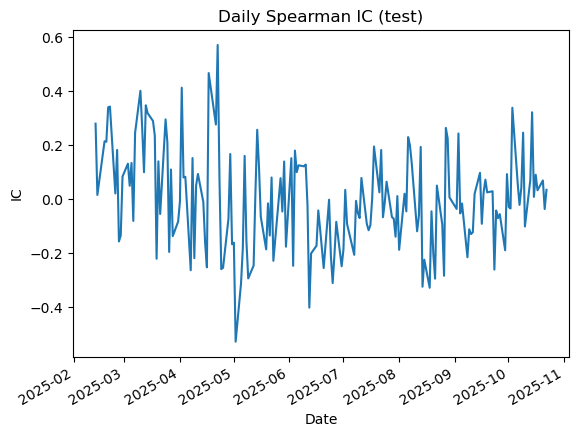

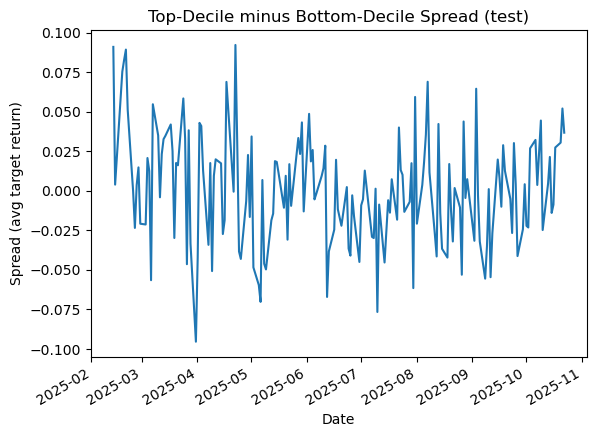

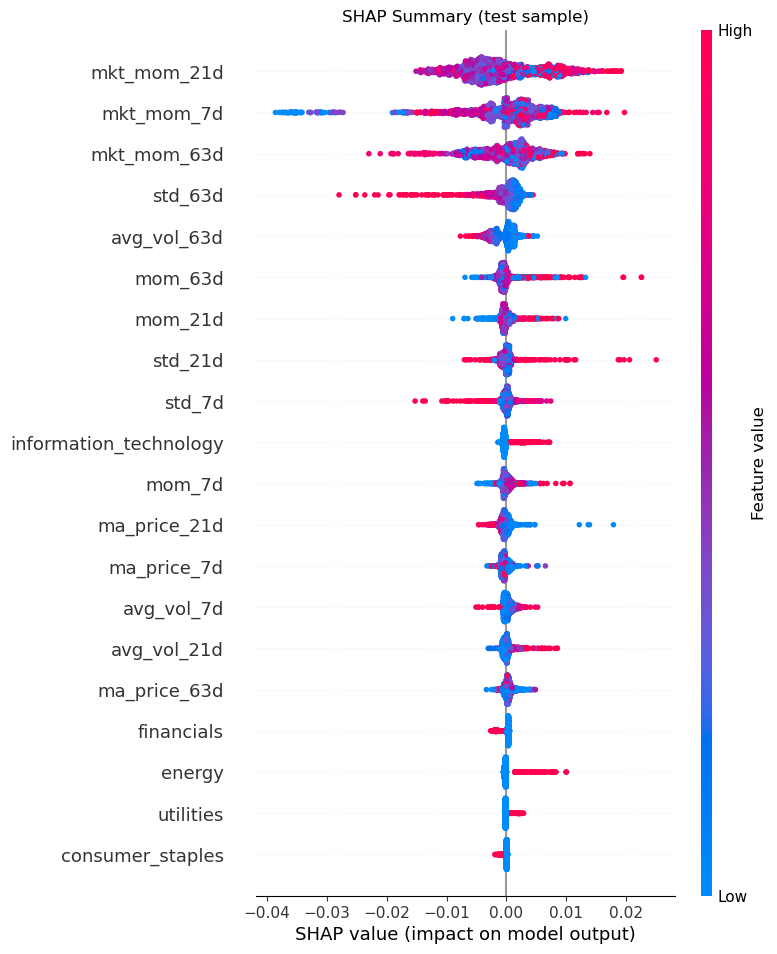

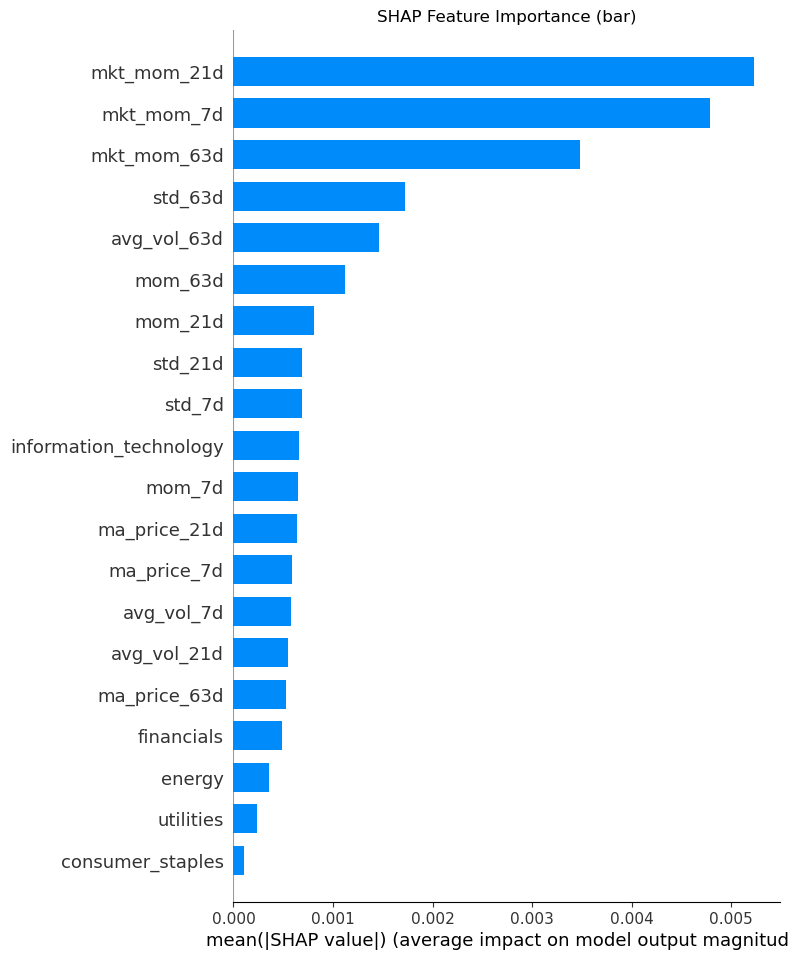

In [20]:
feature_cols = [col for col in merged.columns if col not in ['date', 'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock_splits', 'ticker']]
feature_cols = [col for col in feature_cols if 'out_' not in col]
feature_cols = [col for col in feature_cols if 'date' not in col]

model, metrics = train_xgb_and_benchmark(merged.rename(columns = {'date_x': 'date'}).fillna(0), feature_cols, target_col="out_ret_7d")

In [21]:
metrics

{'train': {'rmse': 0.042951019553484744,
  'mae': 0.030385541746505235,
  'r2': 0.2700075563277772},
 'valid': {'rmse': 0.05053809787811625,
  'mae': 0.035892998719283045,
  'r2': -0.05040826631565598},
 'test': {'rmse': 0.05573124303945928,
  'mae': 0.039447997007251503,
  'r2': -0.08072603604052042,
  'mean_spearman_ic': -0.0015711335729786593,
  'avg_top_minus_bottom_decile': 0.000648314717549436},
 'split': {'train_end': '2024-06-03 04:00:00+00:00',
  'valid_end': '2025-02-12 05:00:00+00:00'}}